 # Setup & Google Drive Connect

In [4]:

from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/drive/MyDrive/dataset/'

TRAIN_PATH = '/content/drive/MyDrive/dataset/train'
VALID_PATH = '/content/drive/MyDrive/dataset/test'
TEST_PATH  = '/content/drive/MyDrive/dataset/valid'

print('Google Drive Connected Successfully ')

Mounted at /content/drive
Google Drive Connected Successfully 


# import Libraries

In [5]:
#  Install Libraries
!pip install torch torchvision torchaudio --quiet
!pip install ultralytics --quiet    # YOLOv8 ke liye
!pip install timm --quiet           # Transfer Learning models

#  Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torchvision.utils import make_grid

# Metrics
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, f1_score)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries Imported!')
print(f'   Device: {device}')
print(f'   PyTorch Version: {torch.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 73.0 MB/s eta 0:00:00
✅ Libraries Imported!
   Device: cuda
   PyTorch Version: 2.10.0+cu128


# Dataset Explore

In [6]:
import os

def count_images(path):
    counts = {}
    for class_name in os.listdir(path):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

print('─── Dataset Overview ───')
print('\nTRAIN:')
train_counts = count_images(TRAIN_PATH)
for cls, count in train_counts.items():
    print(f'  {cls}: {count} images')

print('\nVALID:')
valid_counts = count_images(VALID_PATH)
for cls, count in valid_counts.items():
    print(f'  {cls}: {count} images')

print('\nTEST:')
test_counts = count_images(TEST_PATH)
for cls, count in test_counts.items():
    print(f'  {cls}: {count} images')

total = sum(train_counts.values()) + sum(valid_counts.values()) + sum(test_counts.values())
print(f'\nTotal Images: {total}')

─── Dataset Overview ───

TRAIN:
  drone: 1248 images
  bird: 1414 images

VALID:
  bird: 121 images
  drone: 94 images

TEST:
  bird: 217 images
  drone: 225 images

Total Images: 3319


# Sample Images Visualize

# **row = 0 , cla = bird or image in data**
# **index, value**
# **col** = 0 , img_name = name of image**
# **index, image_namet**

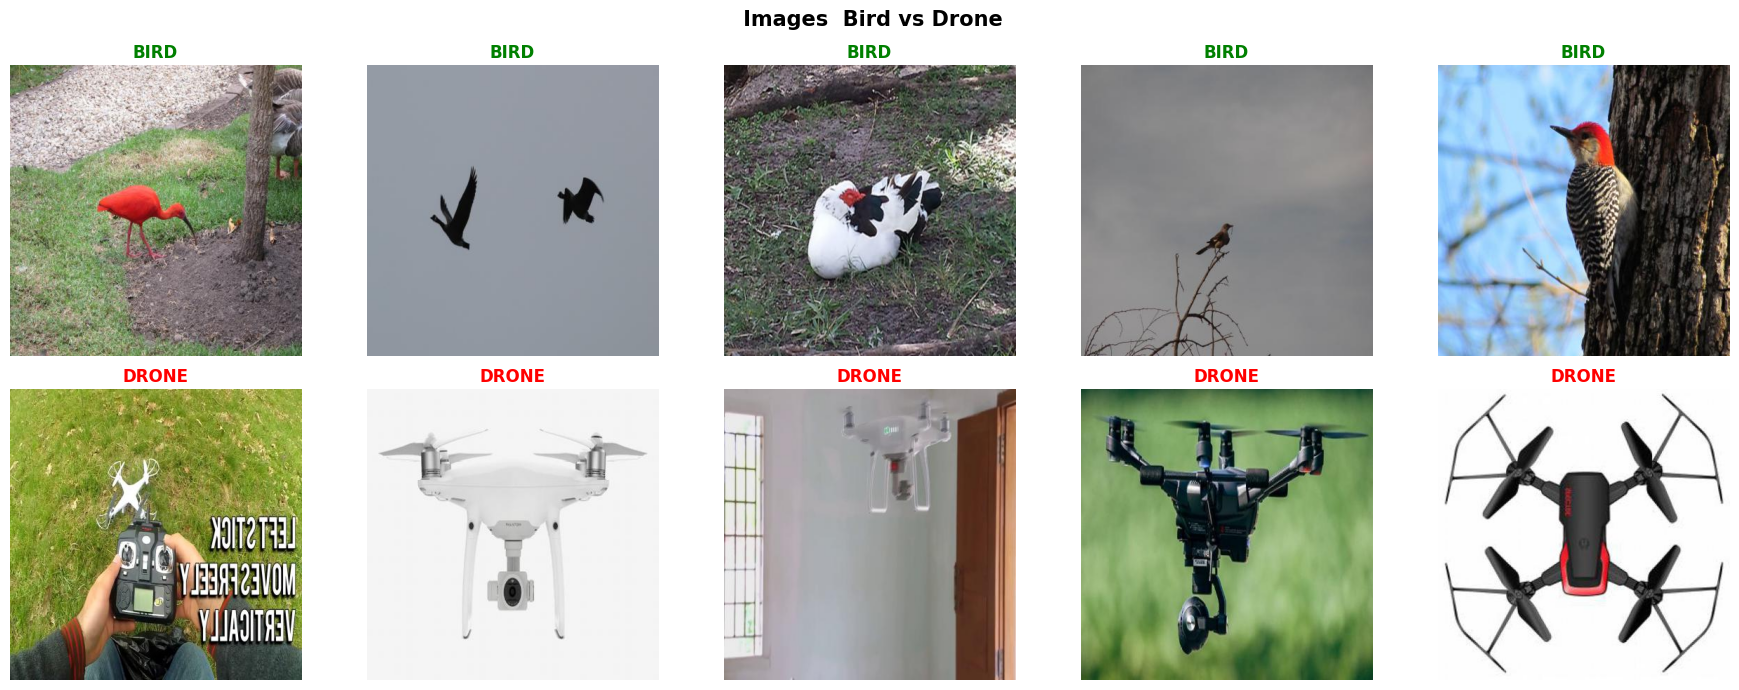

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
classes   = ['bird', 'drone']

for row, cla in enumerate(classes):
    cla_path = os.path.join(TRAIN_PATH, cla)
    img  = os.listdir(cla_path)[:5]

    for col, img_name in enumerate(img):
        img_path = os.path.join(cla_path, img_name)
        img = Image.open(img_path).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(f'{cla.upper()}', fontweight='bold',color='green'
                                 if cla == 'bird' else 'red')
        axes[row][col].axis('off')

plt.suptitle(' Images  Bird vs Drone', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Image Properties Analysis

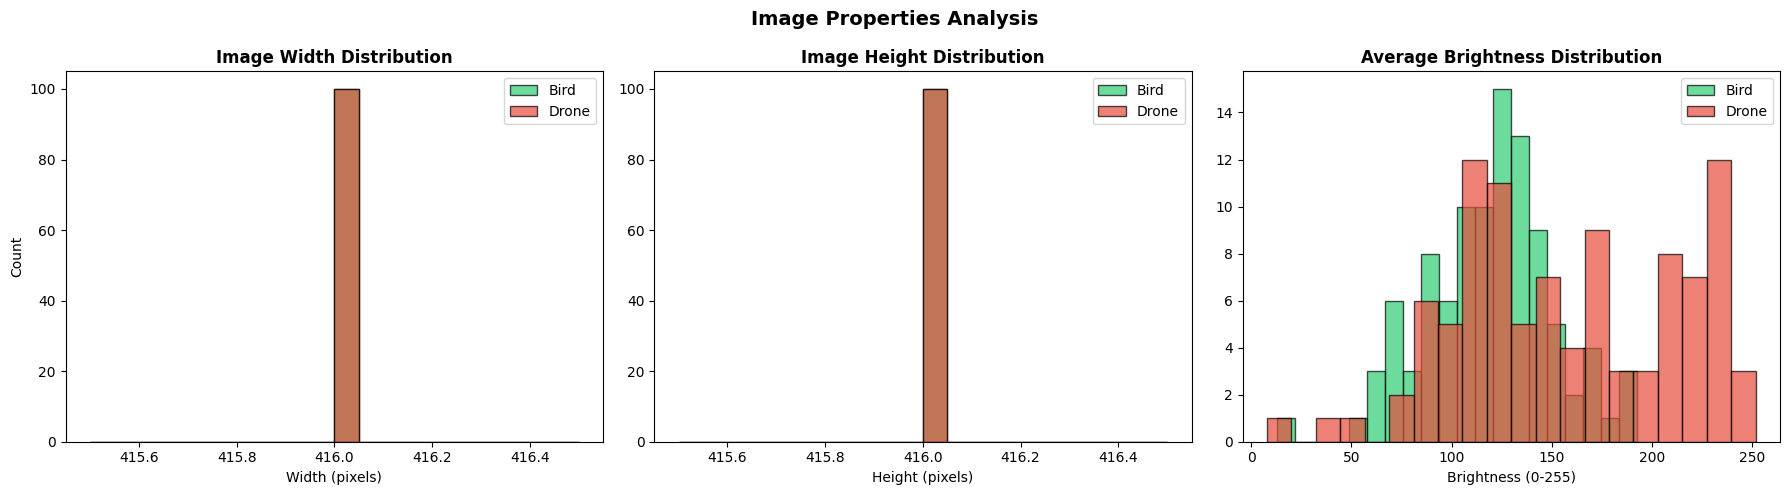

Bird  — Avg Width: 416px, Avg Height: 416px
Drone — Avg Width: 416px, Avg Height: 416px


In [8]:
# Image sizes, brightness etc analyze karo
# Yeh jaanna zaroori hai preprocessing ke liye

widths_bird, heights_bird   = [], []
widths_drone, heights_drone = [], []
bright_bird, bright_drone   = [], []

for cls, wlist, hlist, blist in [
    ('bird',  widths_bird,  heights_bird,  bright_bird),
    ('drone', widths_drone, heights_drone, bright_drone)
]:
    cls_path = os.path.join(TRAIN_PATH, cls)
    for img_name in os.listdir(cls_path)[:100]:   # 100 images sample
        img_path = os.path.join(cls_path, img_name)
        try:
            img = Image.open(img_path).convert('RGB')
            w, h = img.size
            wlist.append(w)
            hlist.append(h)
            blist.append(np.array(img).mean())
        except:
            continue

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Image Properties Analysis', fontsize=14, fontweight='bold')

# Width distribution
axes[0].hist(widths_bird,  bins=20, alpha=0.7, color='#2ecc71', label='Bird',  edgecolor='black')
axes[0].hist(widths_drone, bins=20, alpha=0.7, color='#e74c3c', label='Drone', edgecolor='black')
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Height distribution
axes[1].hist(heights_bird,  bins=20, alpha=0.7, color='#2ecc71', label='Bird',  edgecolor='black')
axes[1].hist(heights_drone, bins=20, alpha=0.7, color='#e74c3c', label='Drone', edgecolor='black')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].legend()

# Brightness
axes[2].hist(bright_bird,  bins=20, alpha=0.7, color='#2ecc71', label='Bird',  edgecolor='black')
axes[2].hist(bright_drone, bins=20, alpha=0.7, color='#e74c3c', label='Drone', edgecolor='black')
axes[2].set_title('Average Brightness Distribution', fontweight='bold')
axes[2].set_xlabel('Brightness (0-255)')
axes[2].legend()

plt.tight_layout()
plt.savefig('image_properties.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Bird  — Avg Width: {np.mean(widths_bird):.0f}px, Avg Height: {np.mean(heights_bird):.0f}px')
print(f'Drone — Avg Width: {np.mean(widths_drone):.0f}px, Avg Height: {np.mean(heights_drone):.0f}px')

# Data Preprocessing & Augmentation

In [12]:

img_size = 224   # Standard size for most of the models images
batch   = 32    # ek baar me 32 images model ko jayengi

# Training transform technique for Augmentation  and  Normalization

train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(p=0.5),     # 50% chance flip
    transforms.RandomVerticalFlip(p=0.2),        # 20% chance flip
    transforms.RandomRotation(degrees=20),        # +-20 degree rotate
    transforms.ColorJitter(
        brightness=0.3,                           # brightness change
        contrast=0.3,                             # contrast change
        saturation=0.2                            # color saturation
    ),
    transforms.RandomResizedCrop(
        img_size, scale=(0.8, 1.0)               # random crop
    ),
    transforms.ToTensor(),                        # PIL to Tensor
    transforms.Normalize(                         # ImageNet mean/std
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Validation/Test transforms  technique only Resize and Normalization
val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(
     mean=[0.485, 0.456, 0.406],
                                      #  Data ko scale karta hai
                                      #  Faster + stable training
                                      #  Pretrained models ke liye must
     std=[0.229, 0.224, 0.225])

])

#   Load Datasets
train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transforms)
valid_dataset = datasets.ImageFolder(VALID_PATH, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_PATH,  transform=val_test_transforms)

#   DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch,shuffle=True,  num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch,shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch,shuffle=False, num_workers=2, pin_memory=True)

# Classes
class_names = train_dataset.classes
print(f'   Data Loaded ')
print(f'   Class    :    {class_names}')
print(f'   Train size  : {len(train_dataset)}')
print(f'   Valid size  : {len(valid_dataset)}')
print(f'   Test  size  : {len(test_dataset)}')
print(f'   Batch size  : {batch}')

   Data Loaded 
   Class    : ['bird', 'drone']
   Train size  : 2662
   Valid size  : 215
   Test  size  : 442
   Batch size  : 32


# Augmentation Visualization

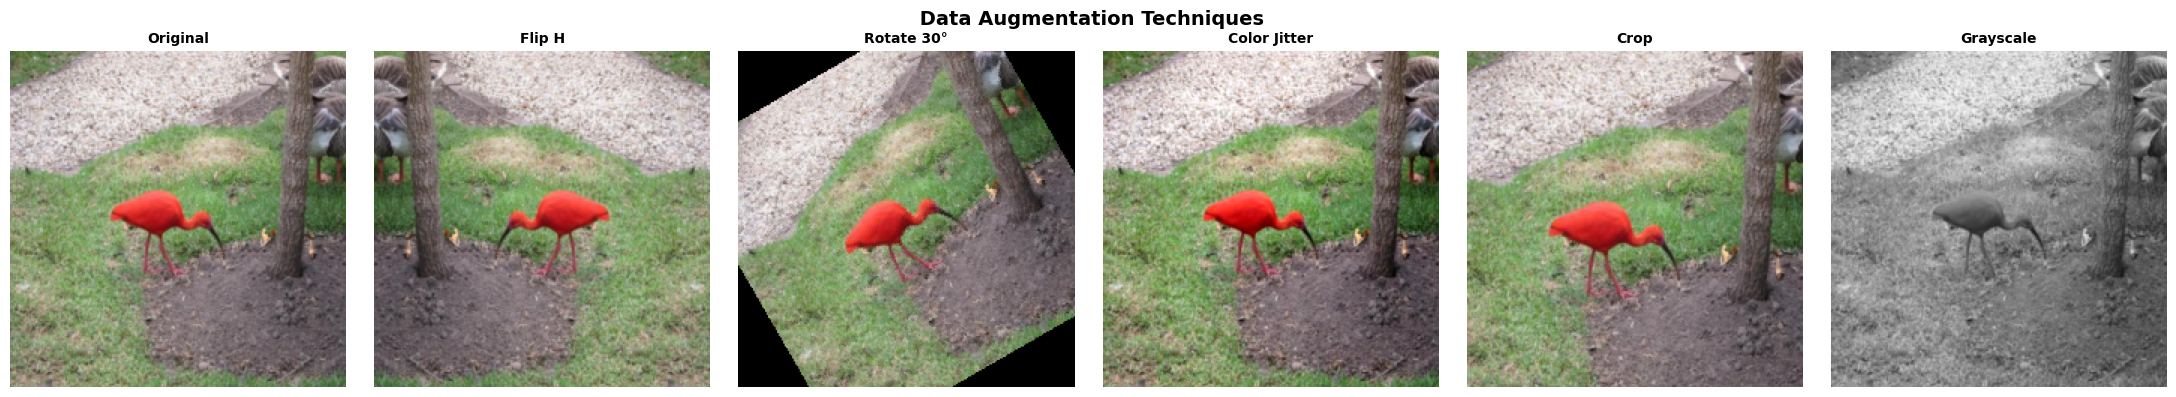

In [14]:
# Augmentation kaise kaam karta hai Visulization
import os
sample_img_path = os.path.join(TRAIN_PATH, 'bird', os.listdir(os.path.join(TRAIN_PATH, 'bird'))[0])
original_img= Image.open(sample_img_path).convert('RGB')

aug_transform = {
    'Original'    : transforms.Compose([transforms.Resize((img_size, img_size))]),
    'Flip H'      : transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomHorizontalFlip(p=1.0)]),
    'Rotate 30°'  : transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomRotation((30, 30))]),
    'Color Jitter': transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ColorJitter(brightness=0.5, contrast=0.5)]),
    'Crop'        : transforms.Compose([transforms.Resize((256, 256)), transforms.RandomCrop(224)]),
    'Grayscale'   : transforms.Compose([transforms.Resize((img_size, img_size)), transforms.Grayscale(num_output_channels=3)]),
}

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
fig.suptitle(' Data Augmentation Techniques', fontsize=14, fontweight='bold')

for ax, (name, transform) in zip(axes, aug_transform.items()):
    aug_img = transform(original_img)
    ax.imshow(aug_img)
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()

# Custom CNN Model (PyTorch)

In [16]:
# Custom CNN Model
class CustomCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CustomCNN, self).__init__()
        # Feature Extraction Layers
        self.features = nn.Sequential(

            # Block 1 — 3 → 32 channels
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 224 → 112
            nn.Dropout2d(0.1),

            # Block 2 — 32 → 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 112 → 56
            nn.Dropout2d(0.2),

            # Block 3 — 64 → 128 channels
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 56 → 28
            nn.Dropout2d(0.3),

            # Block 4 — 128 → 256 channels
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),        # 28 → 14
            nn.Dropout2d(0.3),
        )

        #  Classifier
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),   # 14 → 4x4
            nn.Flatten(),                    # 256*4*4 = 4096
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Model banao
cnn_model = CustomCNN(num_classes=2).to(device)

# Model summary
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f' Custom CNN Ready!')
print(f'   Total Parameters: {total_params:,}')
print(cnn_model)

 Custom CNN Ready!
   Total Parameters: 2,748,194
CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.1, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool

# Training Function

In [21]:
# ─ Training & Validation Function

def train_model(model, train_loader, valid_loader,
                num_epochs=30, lr=0.001, model_name='model'):

    # Loss aur Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Learning Rate Scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

    # History track karo
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }

    best_val_acc = 0.0
    patience_counter = 0
    PATIENCE = 7   # EarlyStopping

    print(f'\n Training {model_name} Started...')
    print('='*60)

    for epoch in range(num_epochs):

        # TRAIN PHASE
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Stats
            train_loss    += loss.item()
            _, predicted   = outputs.max(1)
            train_total   += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc  = 100. * train_correct / train_total

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images  = images.to(device)
                labels  = labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)

                val_loss    += loss.item()
                _, predicted = outputs.max(1)
                val_total   += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        avg_val_loss = val_loss / len(valid_loader)
        avg_val_acc  = 100. * val_correct / val_total

        # Scheduler step
        scheduler.step(avg_val_loss)

        # History save
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        # Best model save
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            patience_counter = 0
            saved = ' Saved!'
        else:
            patience_counter += 1
            saved = ''

        print(f'Epoch [{epoch+1:2d}/{num_epochs}] '
              f'Train Loss: {avg_train_loss:.4f} '
              f'Train Acc: {avg_train_acc:.2f}% '
              f'Val Loss: {avg_val_loss:.4f} '
              f'Val Acc: {avg_val_acc:.2f}% {saved}')

        # EarlyStopping
        if patience_counter >= PATIENCE:
            print(f'\n⏹ Early Stopping at Epoch {epoch+1}')
            break

    print(f'\n Best Validation Accuracy: {best_val_acc:.2f}%')
    return history

# CNN Train

In [24]:
cnn_history = train_model(
    model       = cnn_model,
    train_loader = train_loader,
    valid_loader = valid_loader,
    num_epochs  = 30,
    lr          = 0.001,
    model_name  = 'custom_cnn'
)


🚀 Training custom_cnn Started...
Epoch [ 1/30] Train Loss: 0.6145 Train Acc: 67.13% Val Loss: 0.5681 Val Acc: 64.19%  Saved!
Epoch [ 2/30] Train Loss: 0.5682 Train Acc: 70.14% Val Loss: 0.4246 Val Acc: 77.21%  Saved!
Epoch [ 3/30] Train Loss: 0.5366 Train Acc: 72.92% Val Loss: 0.4243 Val Acc: 81.40%  Saved!
Epoch [ 4/30] Train Loss: 0.5167 Train Acc: 75.47% Val Loss: 0.3781 Val Acc: 80.00% 
Epoch [ 5/30] Train Loss: 0.5125 Train Acc: 75.43% Val Loss: 0.3866 Val Acc: 86.05%  Saved!
Epoch [ 6/30] Train Loss: 0.4900 Train Acc: 76.56% Val Loss: 0.4124 Val Acc: 80.00% 
Epoch [ 7/30] Train Loss: 0.4688 Train Acc: 78.06% Val Loss: 0.3802 Val Acc: 84.19% 
Epoch [ 8/30] Train Loss: 0.4617 Train Acc: 78.29% Val Loss: 0.4615 Val Acc: 78.60% 
Epoch [ 9/30] Train Loss: 0.4312 Train Acc: 80.47% Val Loss: 0.3215 Val Acc: 86.05% 
Epoch [10/30] Train Loss: 0.4214 Train Acc: 81.56% Val Loss: 0.3205 Val Acc: 85.58% 
Epoch [11/30] Train Loss: 0.4301 Train Acc: 80.09% Val Loss: 0.3608 Val Acc: 84.65% 
Epo

#  Training Curves Plot

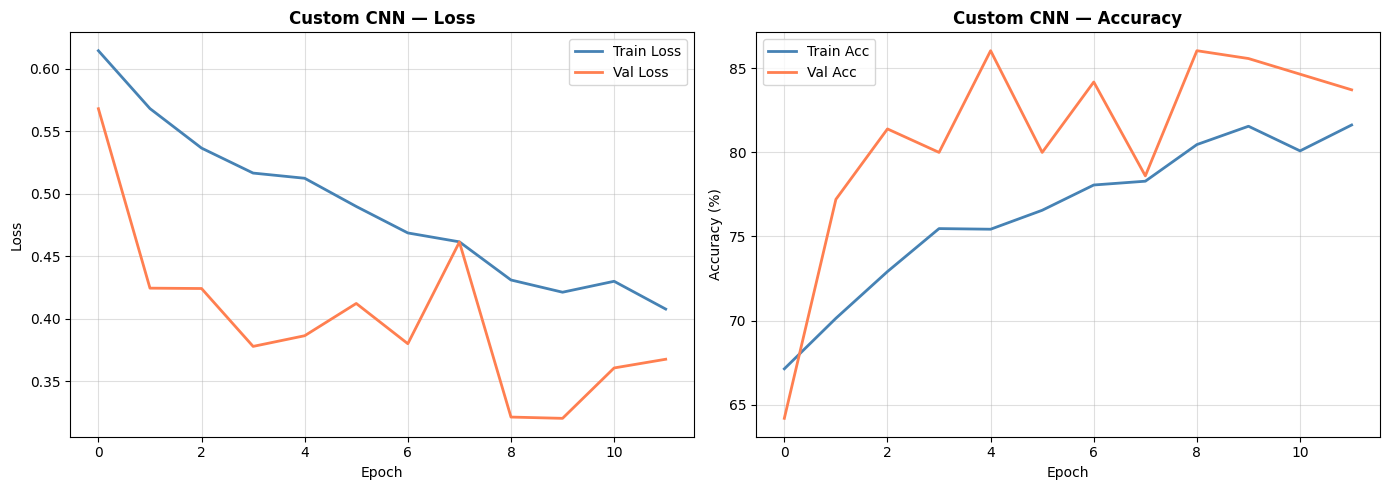

In [25]:
# Plot Training History

def plot_history(history, model_name='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss plot
    axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
    axes[0].plot(history['val_loss'],   label='Val Loss',   color='coral',     linewidth=2)
    axes[0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)

    # Accuracy plot
    axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue', linewidth=2)
    axes[1].plot(history['val_acc'],   label='Val Acc',   color='coral',     linewidth=2)
    axes[1].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig(f'{model_name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(cnn_history, 'Custom CNN')

#  Transfer Learning (ResNet50)

In [26]:
#  Transfer Learning — ResNet50
def build_transfer_model(model_name='resnet50', num_classes=2, freeze=True):

    if model_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        in_features = model.fc.in_features

        # Freeze karo sab layers — sirf last train hogi
        if freeze:
            for param in model.parameters():
                param.requires_grad = False

        # Last layer replace
        model.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    elif model_name == 'mobilenet':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        if freeze:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        if freeze:
            for param in model.parameters():
                param.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, num_classes)
        )

    return model.to(device)

# ResNet50
resnet_model = build_transfer_model('resnet50', num_classes=2, freeze=True)
print(' ResNet50 Transfer Learning Model Ready!')
total_params     = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f'   Total Params    : {total_params:,}')
print(f'   Trainable Params: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 143MB/s]


 ResNet50 Transfer Learning Model Ready!
   Total Params    : 24,033,090
   Trainable Params: 525,058


#  ResNet50 Train


🚀 Training resnet50 Started...
Epoch [ 1/20] Train Loss: 0.3478 Train Acc: 87.90% Val Loss: 0.1547 Val Acc: 95.81%  Saved!
Epoch [ 2/20] Train Loss: 0.2099 Train Acc: 92.00% Val Loss: 0.1190 Val Acc: 96.74%  Saved!
Epoch [ 3/20] Train Loss: 0.1643 Train Acc: 93.88% Val Loss: 0.1029 Val Acc: 97.21%  Saved!
Epoch [ 4/20] Train Loss: 0.1313 Train Acc: 94.55% Val Loss: 0.1024 Val Acc: 96.28% 
Epoch [ 5/20] Train Loss: 0.1381 Train Acc: 95.00% Val Loss: 0.0887 Val Acc: 97.21% 
Epoch [ 6/20] Train Loss: 0.1284 Train Acc: 95.04% Val Loss: 0.0908 Val Acc: 96.28% 
Epoch [ 7/20] Train Loss: 0.1290 Train Acc: 95.15% Val Loss: 0.1026 Val Acc: 96.74% 
Epoch [ 8/20] Train Loss: 0.1110 Train Acc: 95.12% Val Loss: 0.0996 Val Acc: 96.74% 
Epoch [ 9/20] Train Loss: 0.1099 Train Acc: 95.79% Val Loss: 0.0933 Val Acc: 97.67%  Saved!
Epoch [10/20] Train Loss: 0.1291 Train Acc: 95.30% Val Loss: 0.0819 Val Acc: 97.67% 
Epoch [11/20] Train Loss: 0.0973 Train Acc: 96.02% Val Loss: 0.1005 Val Acc: 96.74% 
Epoch

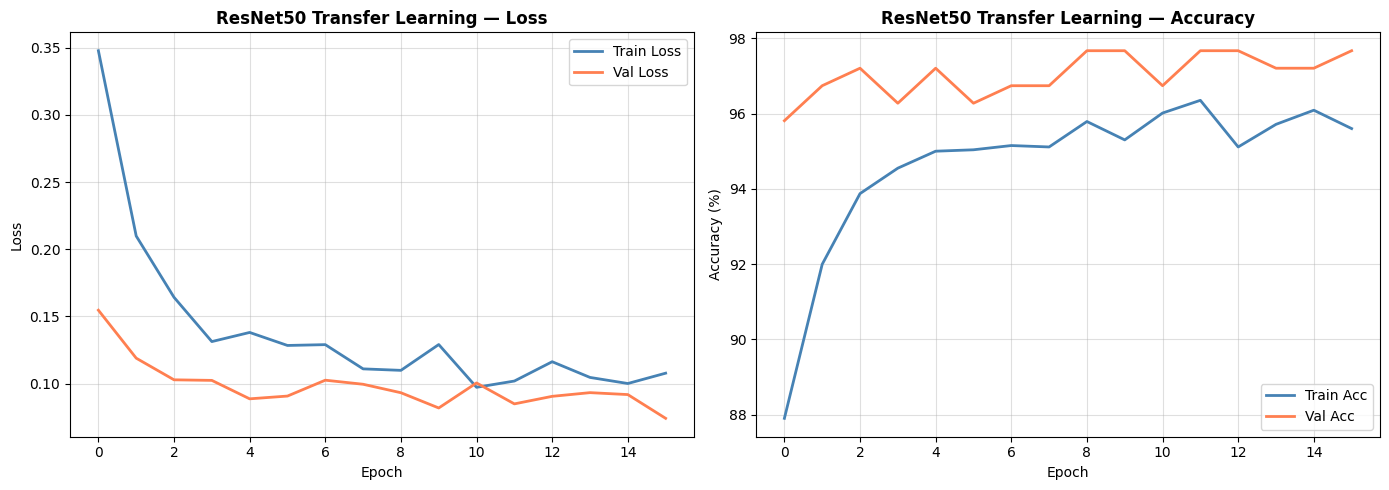

In [27]:
resnet_history = train_model(
    model        = resnet_model,
    train_loader = train_loader,
    valid_loader = valid_loader,
    num_epochs   = 20,
    lr           = 0.0001,
    model_name   = 'resnet50'
)

plot_history(resnet_history, 'ResNet50 Transfer Learning')

#  Evaluation Function


── Custom CNN — Test Results ──
Test Accuracy : 76.92%
F1 Score      : 76.43%

Classification Report:
              precision    recall  f1-score   support

        bird       0.87      0.63      0.73       217
       drone       0.72      0.91      0.80       225

    accuracy                           0.77       442
   macro avg       0.79      0.77      0.76       442
weighted avg       0.79      0.77      0.76       442



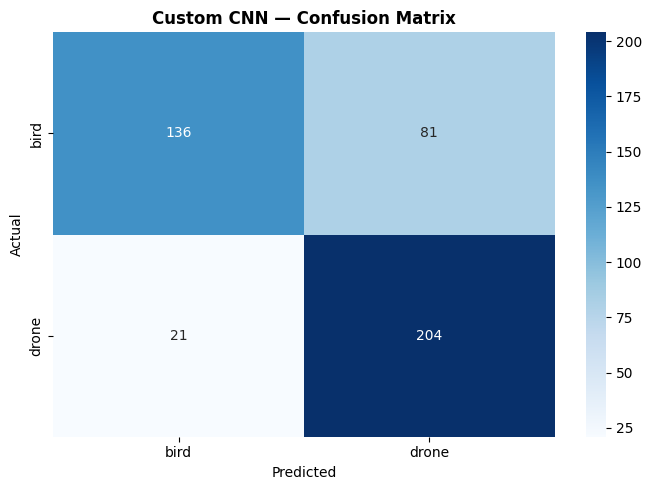


── ResNet50 — Test Results ──
Test Accuracy : 96.38%
F1 Score      : 96.38%

Classification Report:
              precision    recall  f1-score   support

        bird       0.95      0.98      0.96       217
       drone       0.98      0.95      0.96       225

    accuracy                           0.96       442
   macro avg       0.96      0.96      0.96       442
weighted avg       0.96      0.96      0.96       442



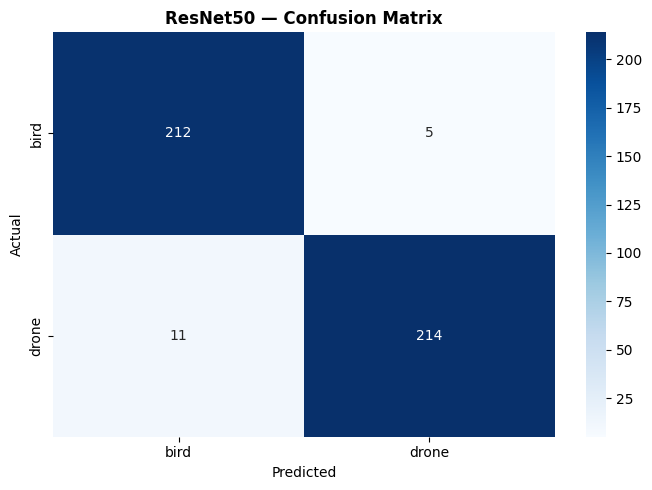

In [28]:
#  Evaluate Model on Test Set

def evaluate_model(model, model_path, test_loader, model_name='Model'):

    # Best weights load karo
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_preds  = []
    all_labels = []
    all_probs  = []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    # Metrics
    acc = accuracy_score(all_labels, all_preds) * 100
    f1  = f1_score(all_labels, all_preds, average='weighted') * 100

    print(f'\n── {model_name} — Test Results ──')
    print(f'Test Accuracy : {acc:.2f}%')
    print(f'F1 Score      : {f1:.2f}%')
    print('\nClassification Report:')
    print(classification_report(all_labels, all_preds,
                                target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'{model_name}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, f1, all_preds, all_labels

# cnn evaluate
cnn_acc, cnn_f1, _, _ = evaluate_model(
    cnn_model, 'best_custom_cnn.pth', test_loader, 'Custom CNN'
)

# resNet50 evaluate
res_acc, res_f1, _, _ = evaluate_model(
    resnet_model, 'best_resnet50.pth', test_loader, 'ResNet50'
)

# Model Comparison


 Model Comparising
            Accuracy  F1 Score
Custom CNN     76.92     76.43
ResNet50       96.38     96.38


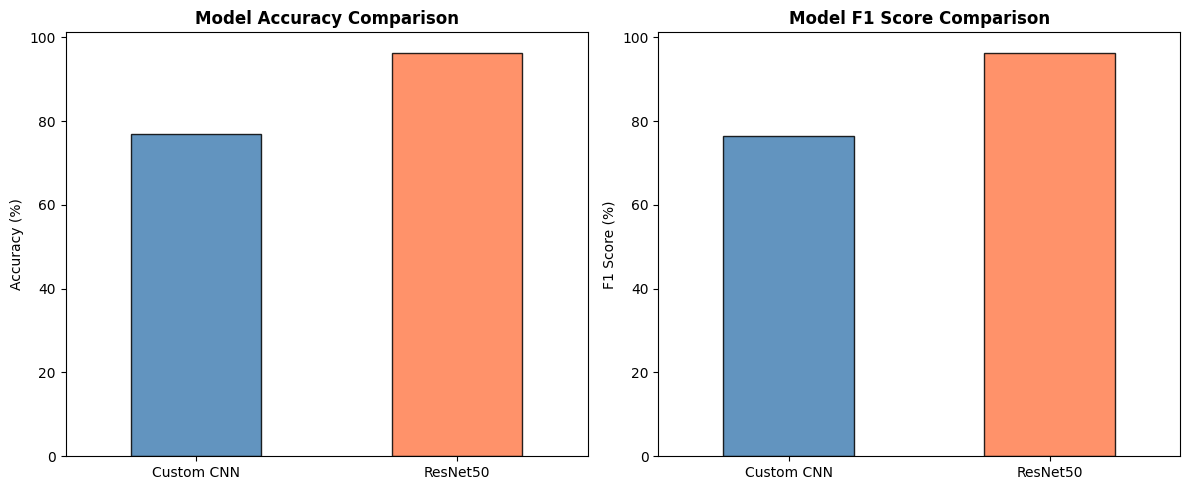


 Best Modelor using in project  f: ResNet50


In [29]:
# Model Comparison
import pandas as pd
models_comparison = {
    'Custom CNN' : {'Accuracy': cnn_acc, 'F1 Score': cnn_f1},'ResNet50'   : {'Accuracy': res_acc, 'F1 Score': res_f1},
}

comparison_df = pd.DataFrame(models_comparison).T
print('\n Model Comparising')
print(comparison_df.round(2))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
comparison_df['Accuracy'].plot(kind='bar', ax=axes[0],color=['steelblue', 'coral'],edgecolor='black', alpha=0.85)
axes[0].set_title('Model Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].tick_params(axis='x', rotation=0)

comparison_df['F1 Score'].plot(kind='bar', ax=axes[1],color=['steelblue', 'coral'], edgecolor='black', alpha=0.85)
axes[1].set_title('Model F1 Score Comparison', fontweight='bold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Best model save
best_model_name = 'ResNet50' if res_acc > cnn_acc else 'Custom CNN'
print(f'\n Best Modelor using in project  f: {best_model_name}')

# YOLOv8 (Object Detection)

In [ ]:
# ── YOLOv8 Setup
!pip install ultralytics -q

from ultralytics import YOLO

# data.yaml banao
yaml_content = """
path: /content/drive/MyDrive/dataset/object_detection
train: train/images
val  : valid/images
test : test/images

nc: 2
names: ['bird', 'drone']
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print('data.yaml created!')

#  YOLOv8 Train
yolo_model = YOLO('yolov8n.pt')   # nano model — fastest

results = yolo_model.train(
    data    = 'data.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    name    = 'aerial_yolo',
    device  = 0 if torch.cuda.is_available() else 'cpu'
)

print(' YOLOv8 Training Complete!')

# Validate
val_results = yolo_model.val()
print(f'mAP50   : {val_results.box.map50:.4f}')
print(f'mAP50-95: {val_results.box.map:.4f}')



✅ data.yaml created!
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aerial_yolo6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspe

FileNotFoundError: No images or videos found in /content/drive/MyDrive/dataset/valid. Supported formats are:
images: {'jpeg2000', 'png', 'heif', 'jp2', 'bmp', 'heic', 'avif', 'tiff', 'mpo', 'webp', 'tif', 'dng', 'jpeg', 'jpg'}
videos: {'ts', 'wmv', 'm4v', 'mpeg', 'mov', 'mkv', 'avi', 'mp4', 'gif', 'asf', 'mpg', 'webm'}

In [ ]:
results = yolo_model.predict(
    source="/content/drive/MyDrive/dataset/object_detection/valid/images",
    save=True,
    conf=0.25
)


image 1/448 /content/drive/MyDrive/dataset/object_detection/valid/images/000b4796f7fb05df_jpg.rf.424af2aea307cff3f4ecfc227b17493e.jpg: 640x640 1 bird, 23.5ms
image 2/448 /content/drive/MyDrive/dataset/object_detection/valid/images/001efa9e9adb51ed_jpg.rf.49044b2928813467b4b523de6e374592.jpg: 640x640 1 bird, 12.8ms
image 3/448 /content/drive/MyDrive/dataset/object_detection/valid/images/002e5a8b293ba55a_jpg.rf.5ba62ed8edc692be4f09e09b093f2200.jpg: 640x640 1 bird, 11.7ms
image 4/448 /content/drive/MyDrive/dataset/object_detection/valid/images/003fc1e9d6110dcc_jpg.rf.1a175dcb19e1247f91035c3401260557.jpg: 640x640 1 bird, 12.0ms
image 5/448 /content/drive/MyDrive/dataset/object_detection/valid/images/00570e9f0f6e1db1_jpg.rf.74c4b8f9a5883a03baf79e60f1a2dacb.jpg: 640x640 1 bird, 47.3ms
image 6/448 /content/drive/MyDrive/dataset/object_detection/valid/images/00584b3a4e064d09_jpg.rf.5879fc9d620fda58e6498df276bd2733.jpg: 640x640 1 bird, 7.3ms
image 7/448 /content/drive/MyDrive/dataset/object_de

(np.float64(-0.5), np.float64(415.5), np.float64(415.5), np.float64(-0.5))

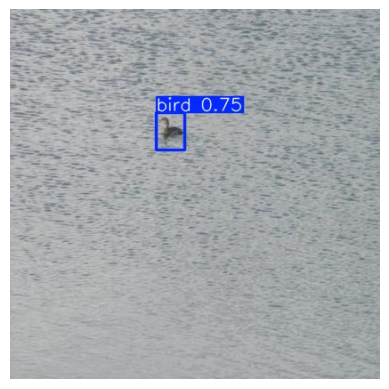

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/predict/000b4796f7fb05df_jpg.rf.424af2aea307cff3f4ecfc227b17493e.jpg")
plt.imshow(img)
plt.axis('off')

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

/content/yolov8n.pt
/content/yolo26n.pt
/content/runs/detect/aerial_yolo4/weights/best.pt
/content/runs/detect/aerial_yolo4/weights/last.pt
/content/runs/detect/aerial_yolo6/weights/best.pt
/content/runs/detect/aerial_yolo6/weights/last.pt


In [ ]:
from google.colab import files

files.download('/content/runs/detect/aerial_yolo6/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>